### Create dataset

In [7]:
import pandas as pd
import numpy as np
from datetime import timedelta

np.random.seed(42)

# -----------------------------
# CONFIG
# -----------------------------
N_CUSTOMERS = 4000
START_DATE = pd.Timestamp("2024-01-01")
END_DATE = pd.Timestamp("2025-06-30")
DATE_RANGE_DAYS = (END_DATE - START_DATE).days

# -----------------------------
# CUSTOMER SEGMENTS
# -----------------------------
segments = {
    "VIP Loyalists": {
        "share": 0.10,
        "base_aov_mean": 140,
        "base_aov_sd": 20,
        "repeat_lambda": 5.5,
        "discount_prob": 0.15,
        "refund_prob": 0.03,
        "days_between_mean": 35
    },
    "Steady Repeaters": {
        "share": 0.30,
        "base_aov_mean": 95,
        "base_aov_sd": 15,
        "repeat_lambda": 3.2,
        "discount_prob": 0.25,
        "refund_prob": 0.05,
        "days_between_mean": 50
    },
    "Promo Shoppers": {
        "share": 0.22,
        "base_aov_mean": 75,
        "base_aov_sd": 15,
        "repeat_lambda": 2.4,
        "discount_prob": 0.70,
        "refund_prob": 0.08,
        "days_between_mean": 60
    },
    "One-Time Buyers": {
        "share": 0.25,
        "base_aov_mean": 65,
        "base_aov_sd": 12,
        "repeat_lambda": 1.1,
        "discount_prob": 0.45,
        "refund_prob": 0.07,
        "days_between_mean": 999
    },
    "Seasonal Gifters": {
        "share": 0.13,
        "base_aov_mean": 105,
        "base_aov_sd": 18,
        "repeat_lambda": 1.8,
        "discount_prob": 0.30,
        "refund_prob": 0.04,
        "days_between_mean": 120
    }
}

segment_names = list(segments.keys())
segment_probs = [segments[s]["share"] for s in segment_names]

# -----------------------------
# CHANNELS
# -----------------------------
channels = {
    "Email": {"share": 0.18, "repeat_boost": 1.45, "aov_boost": 1.15, "discount_boost": 0.85},
    "Organic": {"share": 0.26, "repeat_boost": 1.10, "aov_boost": 1.00, "discount_boost": 0.95},
    "Google": {"share": 0.22, "repeat_boost": 1.00, "aov_boost": 1.05, "discount_boost": 1.00},
    "Facebook": {"share": 0.20, "repeat_boost": 0.70, "aov_boost": 0.85, "discount_boost": 1.35},
    "Referral": {"share": 0.14, "repeat_boost": 1.25, "aov_boost": 1.05, "discount_boost": 0.90},
}
channel_names = list(channels.keys())
channel_probs = [channels[c]["share"] for c in channel_names]

# -----------------------------
# OTHER DIMENSIONS
# -----------------------------
countries = ["UK", "US", "Germany", "France"]
country_probs = [0.60, 0.20, 0.12, 0.08]

devices = ["Mobile", "Desktop", "Tablet"]
device_probs = [0.62, 0.30, 0.08]

categories = {
    "Supplements": {"share": 0.25, "margin": 0.58},
    "Beauty": {"share": 0.22, "margin": 0.62},
    "Home": {"share": 0.18, "margin": 0.45},
    "Accessories": {"share": 0.15, "margin": 0.68},
    "Bundles": {"share": 0.12, "margin": 0.55},
    "Gift Sets": {"share": 0.08, "margin": 0.50}
}
category_names = list(categories.keys())
category_probs = [categories[c]["share"] for c in category_names]

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def random_signup_date():
    return START_DATE + pd.Timedelta(days=np.random.randint(0, DATE_RANGE_DAYS + 1))

def seasonal_multiplier(date):
    month = date.month
    # modest seasonality with stronger Q4
    month_map = {
        1: 0.95, 2: 0.94, 3: 1.00, 4: 1.02, 5: 1.03, 6: 0.98,
        7: 0.96, 8: 0.97, 9: 1.01, 10: 1.08, 11: 1.25, 12: 1.45
    }
    return month_map[month]

def choose_category(segment):
    if segment == "Seasonal Gifters":
        probs = np.array([0.12, 0.18, 0.16, 0.10, 0.14, 0.30])
    elif segment == "VIP Loyalists":
        probs = np.array([0.20, 0.24, 0.14, 0.16, 0.18, 0.08])
    elif segment == "Promo Shoppers":
        probs = np.array([0.22, 0.18, 0.20, 0.20, 0.12, 0.08])
    else:
        probs = np.array(category_probs)
    probs = probs / probs.sum()
    return np.random.choice(category_names, p=probs)

def get_discount_rate(segment, channel, used_discount):
    if not used_discount:
        return 0.0

    base_ranges = {
        "VIP Loyalists": (0.05, 0.10),
        "Steady Repeaters": (0.08, 0.15),
        "Promo Shoppers": (0.15, 0.30),
        "One-Time Buyers": (0.10, 0.22),
        "Seasonal Gifters": (0.08, 0.18)
    }

    low, high = base_ranges[segment]
    rate = np.random.uniform(low, high)

    if channel == "Facebook":
        rate *= 1.08
    elif channel == "Email":
        rate *= 0.95

    return min(rate, 0.35)

def get_refund_amount(net_revenue, refund_prob):
    refunded = np.random.random() < refund_prob
    if not refunded:
        return 0.0
    return net_revenue * np.random.uniform(0.30, 1.00)

# -----------------------------
# CREATE CUSTOMERS
# -----------------------------
customer_rows = []

for i in range(1, N_CUSTOMERS + 1):
    segment = np.random.choice(segment_names, p=segment_probs)
    channel = np.random.choice(channel_names, p=channel_probs)
    country = np.random.choice(countries, p=country_probs)
    device = np.random.choice(devices, p=device_probs)
    signup_date = random_signup_date()

    base_aov = np.random.normal(
        segments[segment]["base_aov_mean"],
        segments[segment]["base_aov_sd"]
    )
    base_aov *= channels[channel]["aov_boost"]
    base_aov = max(base_aov, 25)

    repeat_score = segments[segment]["repeat_lambda"] * channels[channel]["repeat_boost"]
    discount_prob = min(segments[segment]["discount_prob"] * channels[channel]["discount_boost"], 0.90)

    customer_rows.append({
        "customer_id": f"C{i:05d}",
        "signup_date": signup_date,
        "acquisition_channel": channel,
        "country": country,
        "device_type": device,
        "customer_segment": segment,
        "base_aov": round(base_aov, 2),
        "repeat_score": round(repeat_score, 2),
        "discount_probability": round(discount_prob, 2),
        "refund_probability": segments[segment]["refund_prob"]
    })

customers = pd.DataFrame(customer_rows)

# -----------------------------
# CREATE ORDERS
# -----------------------------
order_rows = []
order_id_counter = 1

for _, cust in customers.iterrows():
    segment = cust["customer_segment"]
    channel = cust["acquisition_channel"]
    signup_date = cust["signup_date"]
    base_aov = cust["base_aov"]
    repeat_score = cust["repeat_score"]
    discount_probability = cust["discount_probability"]
    refund_probability = cust["refund_probability"]

    # generate number of orders
    if segment == "One-Time Buyers":
        n_orders = 1 if np.random.random() < 0.78 else np.random.choice([2, 3], p=[0.75, 0.25])
    else:
        n_orders = max(1, np.random.poisson(repeat_score))

    order_date = signup_date

    for n in range(1, n_orders + 1):
        if order_date > END_DATE:
            break

        category = choose_category(segment)
        category_margin = categories[category]["margin"]

        season_mult = seasonal_multiplier(order_date)

        gross_revenue = np.random.normal(base_aov * season_mult, base_aov * 0.18)
        gross_revenue = max(gross_revenue, 20)

        # Make one-time buyers lower value
        if segment == "One-Time Buyers":
            gross_revenue *= 0.85

        # units rise slightly with lower-value segments and promo buyers
        if segment in ["Promo Shoppers", "One-Time Buyers"]:
            units = np.random.choice([1, 2, 3, 4], p=[0.35, 0.35, 0.20, 0.10])
        else:
            units = np.random.choice([1, 2, 3], p=[0.50, 0.35, 0.15])

        used_discount = np.random.random() < discount_probability
        discount_rate = get_discount_rate(segment, channel, used_discount)
        
        # Make promo shoppers more discount-heavy (lower profitability)
        if segment == "Promo Shoppers":
            discount_rate = min(discount_rate * 1.15, 0.40)  
        
        discount_amount = gross_revenue * discount_rate
        net_revenue = gross_revenue - discount_amount

        shipping_revenue = np.random.choice([0, 2.99, 3.99, 4.99], p=[0.45, 0.20, 0.25, 0.10])

        cogs = gross_revenue * (1 - category_margin) * np.random.uniform(0.93, 1.07)
        fulfilment_cost = 2.50 + (units * np.random.uniform(0.80, 1.40))
        payment_fee = net_revenue * 0.029 + 0.20
        refund_amount = get_refund_amount(net_revenue, refund_probability)

        net_profit = (net_revenue + shipping_revenue) - cogs - fulfilment_cost - payment_fee - refund_amount

        order_status = np.random.choice(
            ["Completed", "Completed", "Completed", "Completed", "Refunded", "Partially Refunded"],
            p=[0.72, 0.10, 0.08, 0.04, 0.03, 0.03]
        )

        order_rows.append({
            "order_id": f"O{order_id_counter:06d}",
            "customer_id": cust["customer_id"],
            "order_date": order_date,
            "order_number": n,
            "acquisition_channel": channel,
            "country": cust["country"],
            "device_type": cust["device_type"],
            "customer_segment": segment,
            "product_category": category,
            "units": units,
            "gross_revenue": round(gross_revenue, 2),
            "discount_amount": round(discount_amount, 2),
            "net_revenue": round(net_revenue, 2),
            "shipping_revenue": round(shipping_revenue, 2),
            "cogs": round(cogs, 2),
            "fulfilment_cost": round(fulfilment_cost, 2),
            "payment_fee": round(payment_fee, 2),
            "refund_amount": round(refund_amount, 2),
            "net_profit": round(net_profit, 2),
            "profit_margin_pct": round((net_profit / net_revenue) * 100, 2) if net_revenue > 0 else np.nan,
            "used_discount": used_discount,
            "order_status": order_status
        })

        order_id_counter += 1

        # next order timing
        if segment == "One-Time Buyers":
            break

        if segment == "Seasonal Gifters":
            gap = int(np.random.normal(segments[segment]["days_between_mean"], 35))
        else:
            gap = int(np.random.normal(segments[segment]["days_between_mean"], 15))

        gap = max(gap, 7)
        order_date = order_date + pd.Timedelta(days=gap)

orders = pd.DataFrame(order_rows)

# -----------------------------
# ADD DAYS SINCE PRIOR ORDER
# -----------------------------
orders = orders.sort_values(["customer_id", "order_date", "order_number"]).reset_index(drop=True)
orders["days_since_prior_order"] = orders.groupby("customer_id")["order_date"].diff().dt.days

# -----------------------------
# CREATE CUSTOMER SUMMARY METRICS
# -----------------------------
customer_summary = (
    orders.groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue=("net_revenue", "sum"),
        total_profit=("net_profit", "sum"),
        avg_order_value=("net_revenue", "mean"),
        total_refunds=("refund_amount", "sum"),
        discount_order_rate=("used_discount", "mean"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_summary["customer_lifetime_days"] = (
    customer_summary["last_order_date"] - customer_summary["first_order_date"]
).dt.days

customer_summary["repeat_customer"] = customer_summary["total_orders"] > 1

customers = customers.merge(customer_summary, on="customer_id", how="left")

# -----------------------------
# SAVE FILES
# -----------------------------
customers.to_csv("customers.csv", index=False)
orders.to_csv("orders.csv", index=False)

print("customers shape:", customers.shape)
print("orders shape:", orders.shape)
print("\nCustomers preview:")
display(customers.head())
print("\nOrders preview:")
display(orders.head())

customers shape: (4000, 20)
orders shape: (9337, 23)

Customers preview:


,customer_id,signup_date,acquisition_channel,country,device_type,customer_segment,base_aov,repeat_score,discount_probability,refund_probability,total_orders,total_revenue,total_profit,avg_order_value,total_refunds,discount_order_rate,first_order_date,last_order_date,customer_lifetime_days,repeat_customer
0,C00001,2024-05-01,Referral,US,Mobile,Steady Repeaters,104.14,4.00,0.23,0.05,4,394.32,224.43,98.580000,0.00,0.000000,2024-05-01,2024-09-10,132,True
1,C00002,2025-01-20,Email,France,Desktop,One-Time Buyers,88.70,1.59,0.38,0.07,1,73.04,-3.84,73.040000,38.81,0.000000,2025-01-20,2025-01-20,0,False
2,C00003,2025-04-19,Organic,UK,Mobile,Steady Repeaters,79.81,3.52,0.24,0.05,2,137.21,69.44,68.605000,0.00,0.500000,2025-04-19,2025-06-25,67,True
3,C00004,2024-08-31,Organic,UK,Desktop,Steady Repeaters,99.71,3.52,0.24,0.05,3,349.43,194.41,116.476667,0.00,0.333333,2024-08-31,2024-12-12,103,True
4,C00005,2024-06-15,Email,US,Mobile,Promo Shoppers,51.29,3.48,0.59,0.08,3,136.28,58.69,45.426667,0.00,0.333333,2024-06-15,2024-09-20,97,True



Orders preview:


,order_id,customer_id,order_date,order_number,acquisition_channel,country,device_type,customer_segment,product_category,units,...,shipping_revenue,cogs,fulfilment_cost,payment_fee,refund_amount,net_profit,profit_margin_pct,used_discount,order_status,days_since_prior_order
0,O000001,C00001,2024-05-01,1,Referral,US,Mobile,Steady Repeaters,Beauty,2,...,0.00,43.79,4.82,3.56,0.00,63.54,54.92,False,Completed,NaN
1,O000002,C00001,2024-06-29,2,Referral,US,Mobile,Steady Repeaters,Bundles,2,...,2.99,43.79,4.62,3.18,0.00,54.31,52.77,False,Completed,59.0
2,O000003,C00001,2024-07-16,3,Referral,US,Mobile,Steady Repeaters,Supplements,1,...,4.99,33.32,3.84,2.41,0.00,41.67,54.64,False,Completed,17.0
3,O000004,C00001,2024-09-10,4,Referral,US,Mobile,Steady Repeaters,Accessories,1,...,3.99,32.05,3.38,3.08,0.00,64.91,65.28,False,Completed,56.0
4,O000005,C00002,2025-01-20,1,Email,France,Desktop,One-Time Buyers,Gift Sets,2,...,4.99,36.61,4.13,2.32,38.81,-3.84,-5.26,False,Completed,NaN


### Check data

In [8]:
orders.shape
customers.shape
orders['customer_id'].nunique()
orders['order_date'].min(), orders['order_date'].max()
orders.groupby('customer_segment')['order_id'].count().sort_values(ascending=False)

customer_segment
Steady Repeaters    3580
Promo Shoppers      2074
VIP Loyalists       1847
One-Time Buyers      994
Seasonal Gifters     842
Name: order_id, dtype: int64

In [9]:
customer_metrics = (
    orders.groupby('customer_id')
    .agg(
        orders=('order_id', 'count'),
        revenue=('net_revenue', 'sum')
    )
)

customer_metrics['revenue'].describe()

count    4000.000000
mean      228.135182
std       264.320258
min        13.780000
25%        64.135000
50%       129.445000
75%       295.087500
max      2997.190000
Name: revenue, dtype: float64

In [10]:
orders.groupby('acquisition_channel').agg(
    customers=('customer_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    profit=('net_profit', 'sum')
).sort_values('revenue', ascending=False)

,customers,orders,revenue,profit
acquisition_channel,,,,
Organic,1007,2435,236384.78,110139.79
Email,681,1939,215946.52,101664.70
Google,907,2021,202482.19,93289.58
Referral,564,1444,143343.10,65068.45
Facebook,841,1498,114384.14,50083.74


### Create core business metrics

In [11]:
# -----------------------------
# CORE BUSINESS METRICS
# -----------------------------

total_customers = customers['customer_id'].nunique()
total_orders = orders['order_id'].nunique()
total_revenue = orders['net_revenue'].sum()
total_profit = orders['net_profit'].sum()

aov = orders['net_revenue'].mean()
orders_per_customer = total_orders / total_customers

# Repeat customers
repeat_customers = customers[customers['repeat_customer'] == True]['customer_id'].nunique()
repeat_rate = repeat_customers / total_customers

# Revenue split: new vs returning
orders = orders.sort_values(['customer_id', 'order_date'])

orders['is_first_order'] = orders.groupby('customer_id')['order_date'].rank(method='first') == 1

new_customer_revenue = orders[orders['is_first_order']]['net_revenue'].sum()
returning_revenue = orders[~orders['is_first_order']]['net_revenue'].sum()

# Print results
print(f"Total Customers: {total_customers}")
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: £{total_revenue:,.0f}")
print(f"Total Profit: £{total_profit:,.0f}")
print(f"AOV: £{aov:.2f}")
print(f"Orders per Customer: {orders_per_customer:.2f}")
print(f"Repeat Customer Rate: {repeat_rate:.2%}")
print(f"New Customer Revenue: £{new_customer_revenue:,.0f}")
print(f"Returning Customer Revenue: £{returning_revenue:,.0f}")

Total Customers: 4000
Total Orders: 9337
Total Revenue: £912,541
Total Profit: £420,246
AOV: £97.73
Orders per Customer: 2.33
Repeat Customer Rate: 52.20%
New Customer Revenue: £336,452
Returning Customer Revenue: £576,089


### Pareto analysis

In [12]:
# -----------------------------
# PARETO ANALYSIS
# -----------------------------

customer_revenue = (
    orders.groupby('customer_id')['net_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_revenue['cumulative_revenue'] = customer_revenue['net_revenue'].cumsum()
customer_revenue['cumulative_pct'] = customer_revenue['cumulative_revenue'] / customer_revenue['net_revenue'].sum()

customer_revenue['customer_rank_pct'] = (customer_revenue.index + 1) / len(customer_revenue)

# Top 20% contribution
top_20_cutoff = int(0.2 * len(customer_revenue))
top_20_revenue = customer_revenue.iloc[:top_20_cutoff]['net_revenue'].sum()
total_revenue = customer_revenue['net_revenue'].sum()

print(f"Top 20% customers generate {top_20_revenue / total_revenue:.2%} of revenue")

Top 20% customers generate 55.67% of revenue


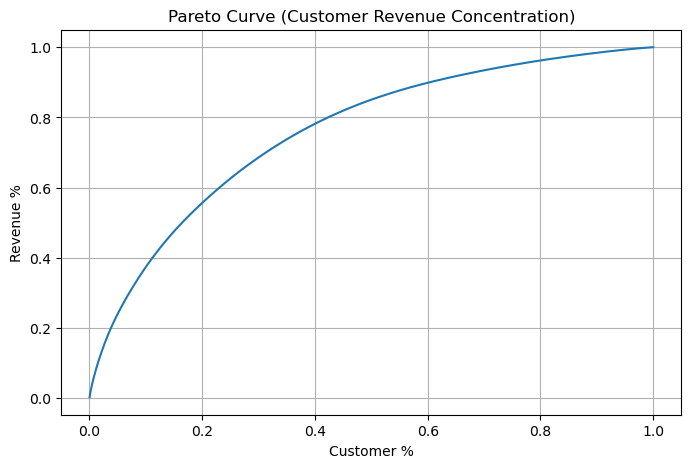

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(customer_revenue['customer_rank_pct'], customer_revenue['cumulative_pct'])
plt.xlabel('Customer %')
plt.ylabel('Revenue %')
plt.title('Pareto Curve (Customer Revenue Concentration)')
plt.grid()
plt.show()

### Channel performance

In [14]:
# -----------------------------
# CHANNEL PERFORMANCE
# -----------------------------

channel_summary = (
    orders.groupby('acquisition_channel')
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('order_id', 'count'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum')
    )
    .reset_index()
)

channel_summary['revenue_per_customer'] = channel_summary['revenue'] / channel_summary['customers']
channel_summary['profit_per_customer'] = channel_summary['profit'] / channel_summary['customers']
channel_summary['orders_per_customer'] = channel_summary['orders'] / channel_summary['customers']

channel_summary = channel_summary.sort_values('revenue', ascending=False)

channel_summary

,acquisition_channel,customers,orders,revenue,profit,revenue_per_customer,profit_per_customer,orders_per_customer
3,Organic,1007,2435,236384.78,110139.79,234.741589,109.374171,2.418073
0,Email,681,1939,215946.52,101664.70,317.102085,149.287372,2.847283
2,Google,907,2021,202482.19,93289.58,223.243870,102.855105,2.228225
4,Referral,564,1444,143343.10,65068.45,254.154433,115.369592,2.560284
1,Facebook,841,1498,114384.14,50083.74,136.009679,59.552604,1.781213


In [15]:
# Repeat rate by channel

repeat_by_channel = (
    customers.groupby('acquisition_channel')
    .agg(
        customers=('customer_id', 'count'),
        repeat_customers=('repeat_customer', 'sum')
    )
    .reset_index()
)

repeat_by_channel['repeat_rate'] = repeat_by_channel['repeat_customers'] / repeat_by_channel['customers']

repeat_by_channel

,acquisition_channel,customers,repeat_customers,repeat_rate
0,Email,681,394,0.578561
1,Facebook,841,346,0.411415
2,Google,907,469,0.517089
3,Organic,1007,556,0.552135
4,Referral,564,323,0.572695


### Customer Segmentation Analysis

In [16]:
# -----------------------------
# SEGMENT PERFORMANCE
# -----------------------------

segment_summary = (
    orders.groupby('customer_segment')
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('order_id', 'count'),
        revenue=('net_revenue', 'sum'),
        profit=('net_profit', 'sum'),
        avg_order_value=('net_revenue', 'mean')
    )
    .reset_index()
)

segment_summary['revenue_per_customer'] = segment_summary['revenue'] / segment_summary['customers']
segment_summary['profit_per_customer'] = segment_summary['profit'] / segment_summary['customers']
segment_summary['orders_per_customer'] = segment_summary['orders'] / segment_summary['customers']

segment_summary = segment_summary.sort_values('revenue', ascending=False)

segment_summary


,customer_segment,customers,orders,revenue,profit,avg_order_value,revenue_per_customer,profit_per_customer,orders_per_customer
3,Steady Repeaters,1248,3580,351289.20,166198.93,98.125475,281.481731,133.172220,2.868590
4,VIP Loyalists,386,1847,279888.88,142629.13,151.537022,725.100725,369.505518,4.784974
1,Promo Shoppers,873,2074,136946.52,48193.30,66.030145,156.868866,55.204238,2.375716
2,Seasonal Gifters,499,842,91490.47,42092.15,108.658515,183.347635,84.353006,1.687375
0,One-Time Buyers,994,994,52925.66,21132.75,53.245131,53.245131,21.260312,1.000000


In [17]:
# Discount usage by segment

discount_summary = (
    orders.groupby('customer_segment')
    .agg(
        discount_rate=('used_discount', 'mean'),
        avg_discount_amount=('discount_amount', 'mean')
    )
    .reset_index()
)

discount_summary

,customer_segment,discount_rate,avg_discount_amount
0,One-Time Buyers,0.469819,4.449839
1,Promo Shoppers,0.686596,13.985395
2,Seasonal Gifters,0.288599,4.292625
3,Steady Repeaters,0.253911,2.871941
4,VIP Loyalists,0.157011,1.723898


In [18]:
# Refund and margin behaviour

profit_quality = (
    orders.groupby('customer_segment')
    .agg(
        refund_rate=('refund_amount', lambda x: (x > 0).mean()),
        avg_profit=('net_profit', 'mean'),
        avg_margin=('profit_margin_pct', 'mean')
    )
    .reset_index()
)

profit_quality

,customer_segment,refund_rate,avg_profit,avg_margin
0,One-Time Buyers,0.077465,21.260312,39.083229
1,Promo Shoppers,0.087271,23.236885,33.242189
2,Seasonal Gifters,0.029691,49.990677,45.626603
3,Steady Repeaters,0.044413,46.424282,46.799291
4,VIP Loyalists,0.027071,77.222052,50.875956
